In [1]:
#load data, merge, inspect basic info for heart disease project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
PATH=""  # leve emplty because both CSVs are in currunt notebook folder

vals=pd.read_csv(PATH + "values.csv")
lbls=pd.read_csv(PATH + "labels.csv")

In [3]:
# inspack the shape of values
print("values shape:",vals.shape)
display(vals.head())

print("\nlabels shape:",lbls.shape)
display(lbls.head())

values shape: (180, 14)


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0



labels shape: (180, 2)


,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0


In [4]:
#find merge column
df=vals.merge(lbls,on='patient_id',how='left')

print("merged DF shape:",df.shape)
display(df.head())

merged DF shape: (180, 15)


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [5]:
# Data types
print("\nData Types:")
display(df.dtypes)


Data Types:


patient_id                               object
slope_of_peak_exercise_st_segment         int64
thal                                     object
resting_blood_pressure                    int64
chest_pain_type                           int64
num_major_vessels                         int64
fasting_blood_sugar_gt_120_mg_per_dl      int64
resting_ekg_results                       int64
serum_cholesterol_mg_per_dl               int64
oldpeak_eq_st_depression                float64
sex                                       int64
age                                       int64
max_heart_rate_achieved                   int64
exercise_induced_angina                   int64
heart_disease_present                     int64
dtype: object

In [6]:
# looking for Missing values
print("\nMissing Values:")
display(df.isna().sum())



Missing Values:


patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

In [7]:
#looking for Target column
if "heart_disease_present" in df.columns:
    print("\nTarget distribution (heart_disease_present):")
    print(df['heart_disease_present'].value_counts())
    print("\nPercentage of class 1:", df['heart_disease_present'].mean()*100, "%")
else:
    print("\nTarget column not found. Tell me target column name.")



Target distribution (heart_disease_present):
heart_disease_present
0    100
1     80
Name: count, dtype: int64

Percentage of class 1: 44.44444444444444 %


In [8]:
#Quick stats
num_cols = df.select_dtypes(include=[np.number]).columns
print("\nNumeric Columns Summary:")
display(df[num_cols].describe().T)


Numeric Columns Summary:


,count,mean,std,min,25%,50%,75%,max
slope_of_peak_exercise_st_segment,180.0,1.550000,0.618838,1.0,1.00,1.0,2.00,3.0
resting_blood_pressure,180.0,131.311111,17.010443,94.0,120.00,130.0,140.00,180.0
chest_pain_type,180.0,3.155556,0.938454,1.0,3.00,3.0,4.00,4.0
num_major_vessels,180.0,0.694444,0.969347,0.0,0.00,0.0,1.00,3.0
fasting_blood_sugar_gt_120_mg_per_dl,180.0,0.161111,0.368659,0.0,0.00,0.0,0.00,1.0
resting_ekg_results,180.0,1.050000,0.998742,0.0,0.00,2.0,2.00,2.0
serum_cholesterol_mg_per_dl,180.0,249.211111,52.717969,126.0,213.75,245.5,281.25,564.0
oldpeak_eq_st_depression,180.0,1.010000,1.121357,0.0,0.00,0.8,1.60,6.2
sex,180.0,0.688889,0.464239,0.0,0.00,1.0,1.00,1.0
age,180.0,54.811111,9.334737,29.0,48.00,55.0,62.00,77.0


# EDA (Exploratory Data Analysis)

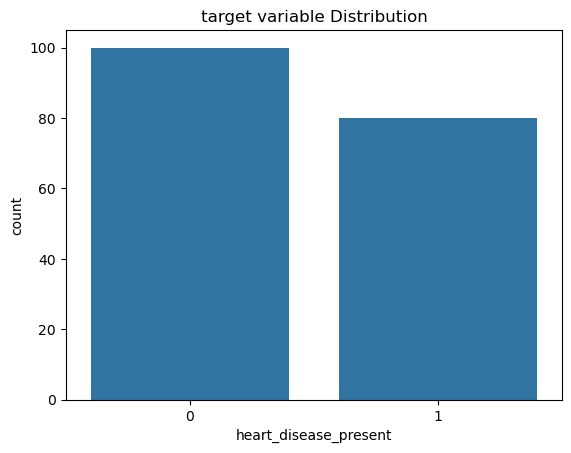

heart_disease_present
0    0.555556
1    0.444444
Name: proportion, dtype: float64


In [9]:
#target variable Disribution
sns.countplot(x='heart_disease_present',data=df)
plt.title('target variable Distribution')
plt.show()

print(df['heart_disease_present'].value_counts(normalize=True))

#### this plot show how many patients have heart disease

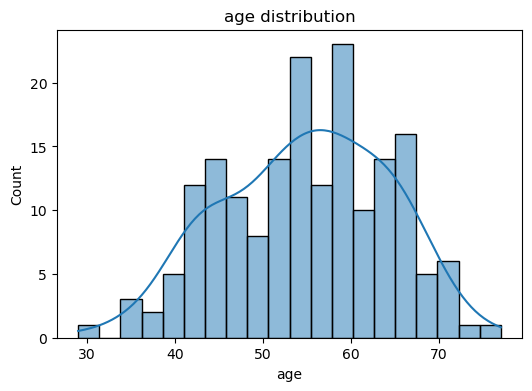

In [10]:
#age distribution
plt.figure(figsize=(6,4))
sns.histplot(df['age'],bins=20,kde=True)
plt.title('age distribution')
plt.show()

#### this plot shows that heart disease risk increases with age

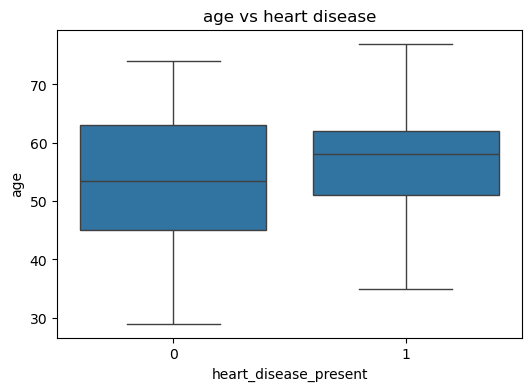

In [11]:
# age vs heart disease
plt.figure(figsize=(6,4))
sns.boxplot(x='heart_disease_present',y='age',data=df)
plt.title('age vs heart disease')
plt.show()

#### patients with heart disease tend to be older.

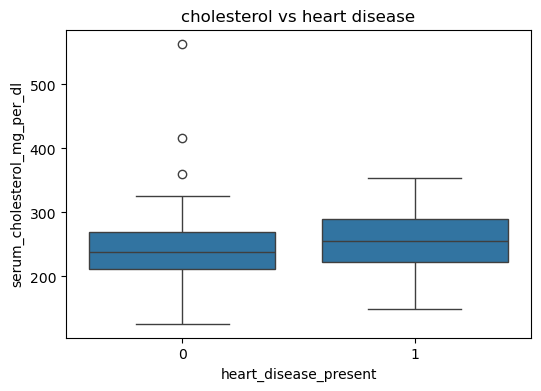

In [12]:
# cholesterol vs heart disease
plt.figure(figsize=(6,4))
sns.boxplot(x='heart_disease_present',y='serum_cholesterol_mg_per_dl',data=df)
plt.title('cholesterol vs heart disease')
plt.show()

#### higher cholesterol increases heart disease risk

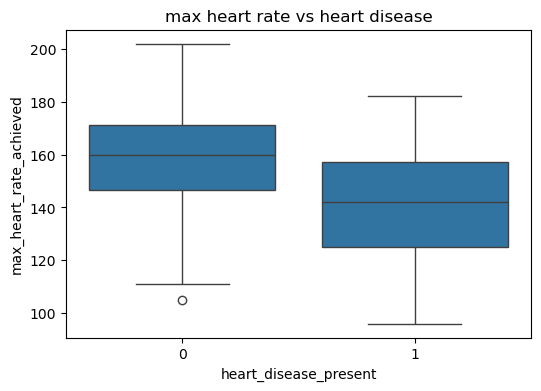

In [13]:
#max heart rate vs heart disease
plt.figure(figsize=(6,4))
sns.boxplot(x='heart_disease_present',y='max_heart_rate_achieved',data=df)
plt.title('max heart rate vs heart disease')
plt.show()

#### lower max heart rate is associated with heart disease

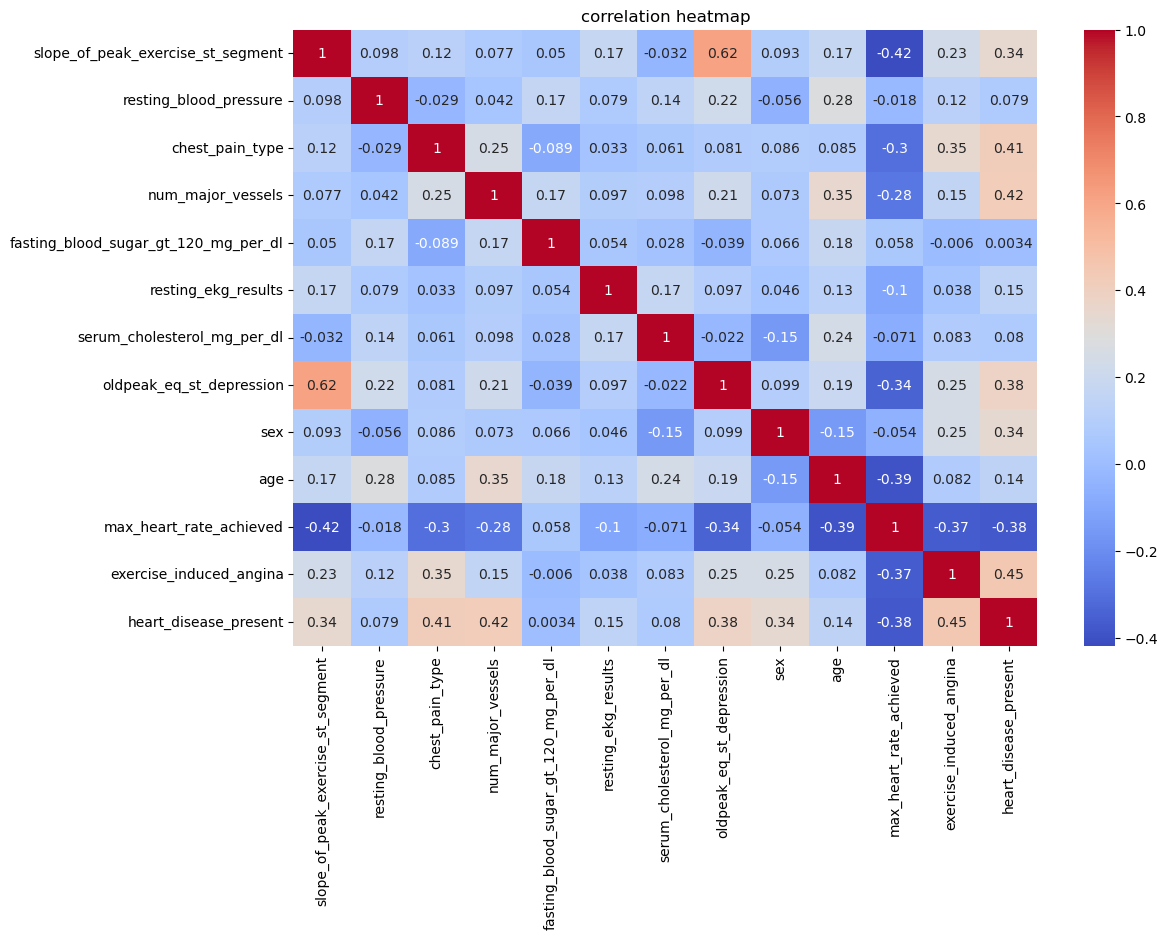

In [14]:
#correlation heatmap
numeric_df=df.select_dtypes(include=['int64','float64']) # convert object values in flot

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

#### identifies strongest features influencing heart disease

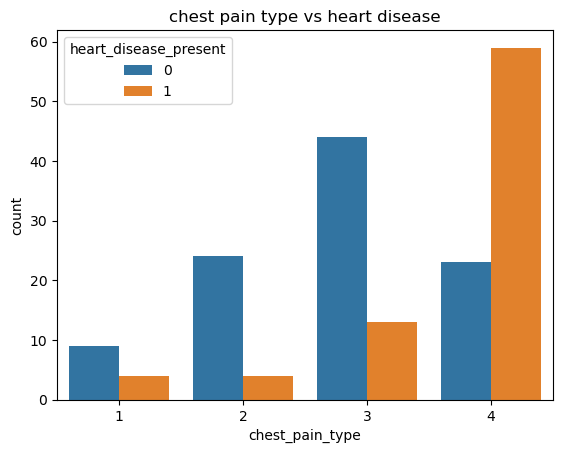

In [15]:
#chest pain type analysis
sns.countplot(x='chest_pain_type',hue='heart_disease_present',data=df)
plt.title('chest pain type vs heart disease')
plt.show()

#### certain chest pain types show higher disease presence

# DATA Cleaning & Preprocessing

In [16]:
#lookin for null values
df.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

In [17]:
#drop unwanted columns
df=df.drop(columns=['patient_id'])

In [18]:
#lable encoding
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
df['thal']=le.fit_transform(df['thal'])

### split fearures & target

In [19]:
x=df.drop('heart_disease_present',axis=1)
y=df['heart_disease_present']

### train_test_split

In [20]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### feature scaling

In [21]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# model building

#### logistic regresion model

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled, y_train)

y_pred_lr = lr.predict(x_test_scaled)
y_prob_lr = lr.predict_proba(x_test_scaled)[:,1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8333333333333334
ROC-AUC Score: 0.9375
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        20
           1       0.78      0.88      0.82        16

    accuracy                           0.83        36
   macro avg       0.83      0.84      0.83        36
weighted avg       0.84      0.83      0.83        36



### random forest

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)
y_prob_rf = rf.predict_proba(x_test)[:,1]

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9166666666666666
ROC-AUC Score: 0.959375
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        20
           1       0.84      1.00      0.91        16

    accuracy                           0.92        36
   macro avg       0.92      0.93      0.92        36
weighted avg       0.93      0.92      0.92        36



### gradient boosting classifier

In [24]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(x_train, y_train)

y_pred_gb = gb.predict(x_test)
y_prob_gb = gb.predict_proba(x_test)[:,1]

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8611111111111112
ROC-AUC Score: 0.9375
              precision    recall  f1-score   support

           0       0.94      0.80      0.86        20
           1       0.79      0.94      0.86        16

    accuracy                           0.86        36
   macro avg       0.87      0.87      0.86        36
weighted avg       0.87      0.86      0.86        36



### model comperision 

In [25]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb)
    ]
})
results

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.833333,0.937500
1,Random Forest,0.916667,0.959375
2,Gradient Boosting,0.861111,0.937500


### BEST MODEL SELECTION 

In [26]:
best_model = results.loc[results['ROC_AUC'].idxmax()]
best_model

Model       Random Forest
Accuracy         0.916667
ROC_AUC          0.959375
Name: 1, dtype: object

# model iterpretatio & Hospital Recommedations

#### key factor influencig heart disease

Based on model behavior and EDA, the most influential factors affecting heart disease prediction include:
Age
-> Chest pain type
-> Maximum heart rate achieved
-> Serum cholesterol level
-> Exercise-induced angina
-> Number of major vessels
-> Resting blood pressure
These features strongly influence whether a patient is at risk of heart disease.

#### model iterpretatio

The selected model (Random Forest) captures complex relationships between clinical features and heart disease presence. Unlike simple linear models, it considers non-linear interactions between age, cholesterol, heart rate, and exercise-related indicators, leading to more accurate predictions.

## suggestios to Hospitals

Use the predictive model as a screening tool to identify high-risk patients during routine check-ups.

Prioritize patients with high cholesterol, abnormal chest pain, and low maximum heart rate for further diagnostic tests.

Implement early intervention programs such as lifestyle counseling, diet management, and regular monitoring for high-risk individuals.

Integrate the model into hospital information systems to assist doctors in data-driven clinical decisions.

Periodically retrain the model with new patient data to maintain accuracy and reliability.